In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn qiskit qiskit-machine-learning pylatexenc


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Setup complete.")

Setup complete.


In [4]:
df = pd.read_csv("cardio_train.csv", sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (70000, 13)


In [5]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [8]:
print("Columns: ")
for col in df.columns:
    print(col)

Columns: 
id
age
gender
height
weight
ap_hi
ap_lo
cholesterol
gluc
smoke
alco
active
cardio


In [11]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [12]:
print(df["cardio"].value_counts())

cardio
0    35021
1    34979
Name: count, dtype: int64


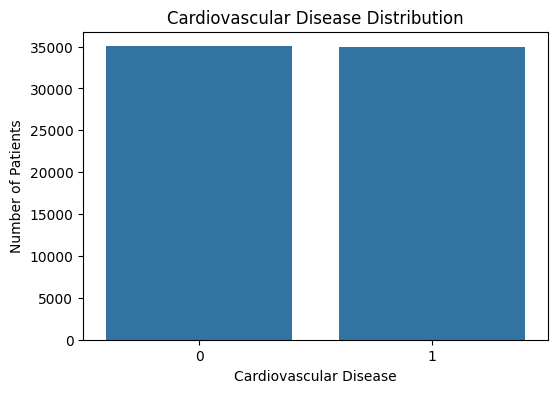

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="cardio")

plt.title("Cardiovascular Disease Distribution")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Number of Patients")

plt.show()

In [14]:
df["age_years"] = df["age"] / 365.25

df[["age", "age_years"]].head()

,age,age_years
0,18393,50.357290
1,20228,55.381246
2,18857,51.627652
3,17623,48.249144
4,17474,47.841205


In [15]:
df = df.drop(columns=["age"])

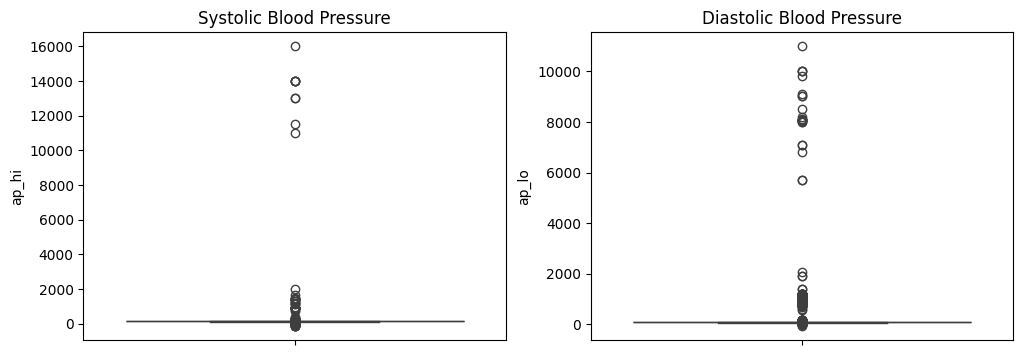

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df["ap_hi"], ax=axes[0])
axes[0].set_title("Systolic Blood Pressure")

sns.boxplot(y=df["ap_lo"], ax=axes[1])
axes[1].set_title("Diastolic Blood Pressure")

plt.show()

In [17]:
before = len(df)

df = df[
    (df["ap_hi"] >= 70) &
    (df["ap_hi"] <= 250) &
    (df["ap_lo"] >= 40) &
    (df["ap_lo"] <= 150) &
    (df["height"] >= 120) &
    (df["height"] <= 220) &
    (df["weight"] >= 30) &
    (df["weight"] <= 200)
].copy()

after = len(df)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("Rows removed:", before - after)

Rows before cleaning: 70000
Rows after cleaning: 68698
Rows removed: 1302


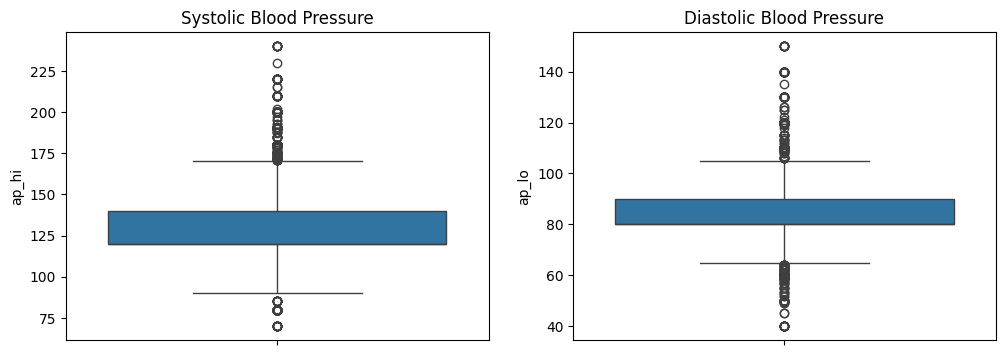

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df["ap_hi"], ax=axes[0])
axes[0].set_title("Systolic Blood Pressure")

sns.boxplot(y=df["ap_lo"], ax=axes[1])
axes[1].set_title("Diastolic Blood Pressure")

plt.show()

In [19]:
df["height_m"] = df["height"] / 100

df["BMI"] = df["weight"] / (df["height_m"] ** 2)

df.drop(columns=["height_m"], inplace=True)

print(df[["height", "weight", "BMI"]].head())

df["BMI"].describe()

   height  weight        BMI
0     168    62.0  21.967120
1     156    85.0  34.927679
2     165    64.0  23.507805
3     169    82.0  28.710479
4     156    56.0  23.011177


count    68698.000000
mean        27.458451
std          5.256957
min         10.726644
25%         23.875115
50%         26.346494
75%         30.116213
max        108.169847
Name: BMI, dtype: float64

In [20]:
df.drop(columns=["id"], inplace=True)
df.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI
0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290,21.967120
1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246,34.927679
2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652,23.507805
3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144,28.710479
4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205,23.011177


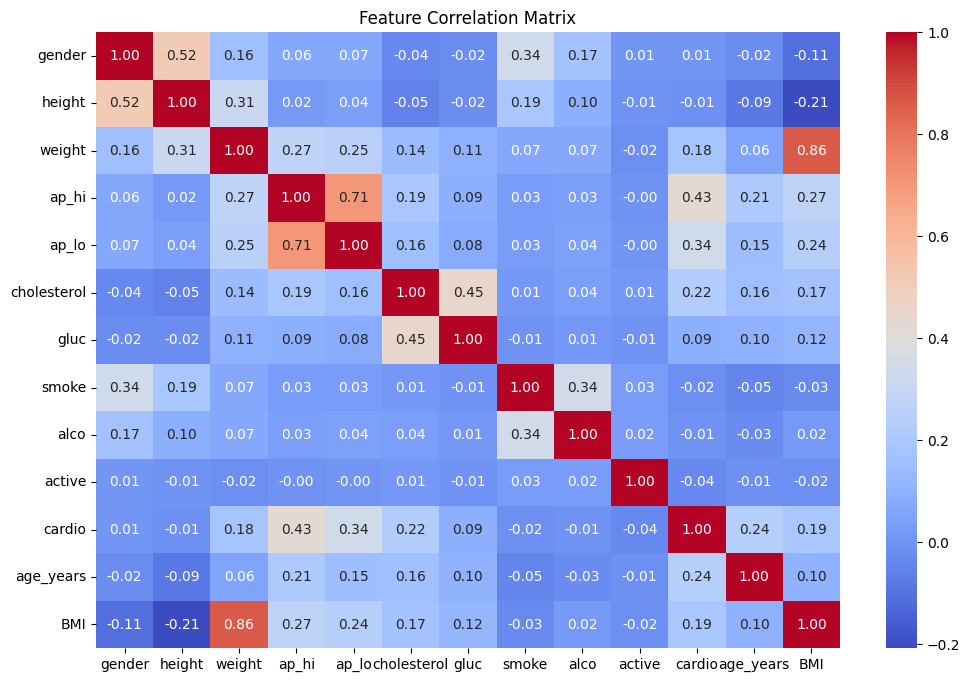

In [21]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [22]:
X = df.drop(columns=["cardio"])
y = df["cardio"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (68698, 12)
y shape: (68698,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 54958
Testing samples: 13740


In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (54958, 12)
Testing shape: (13740, 12)


In [25]:
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

In [26]:
def evaluate_model(name, y_true, y_pred, y_prob):
    
    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Specificity": recall_score(
            y_true,
            y_pred,
            pos_label=0
        ),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }
    
    return results

lr_results = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

lr_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.7307860262008734,
 'Precision': 0.7550180980585719,
 'Recall': 0.6749521988527725,
 'Specificity': 0.7854775968880565,
 'F1': 0.7127436514716161,
 'ROC-AUC': np.float64(0.7953595767439465)}

In [27]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=RANDOM_STATE
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

In [28]:
svm_results = evaluate_model(
    "Classical SVM",
    y_test,
    svm_pred,
    svm_prob
)

svm_results

{'Model': 'Classical SVM',
 'Accuracy': 0.739665211062591,
 'Precision': 0.7647058823529411,
 'Recall': 0.6845124282982792,
 'Specificity': 0.7936896700763578,
 'F1': 0.7223903764066745,
 'ROC-AUC': np.float64(0.7976438690410566)}

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [30]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.7181950509461427,
 'Precision': 0.7187920466437434,
 'Recall': 0.7071628180614796,
 'Specificity': 0.7290015847860539,
 'F1': 0.7129300118623962,
 'ROC-AUC': np.float64(0.7807790110578182)}

In [31]:
classical_results = pd.DataFrame([
    lr_results,
    svm_results,
    rf_results
])

classical_results

,Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC
0,Logistic Regression,0.730786,0.755018,0.674952,0.785478,0.712744,0.795360
1,Classical SVM,0.739665,0.764706,0.684512,0.793690,0.722390,0.797644
2,Random Forest,0.718195,0.718792,0.707163,0.729002,0.712930,0.780779


In [32]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,age_years,0.266093
3,ap_hi,0.161173
11,BMI,0.160474
2,weight,0.115050
1,height,0.110741
4,ap_lo,0.084754
5,cholesterol,0.038019
0,gender,0.017278
6,gluc,0.016699
9,active,0.013707


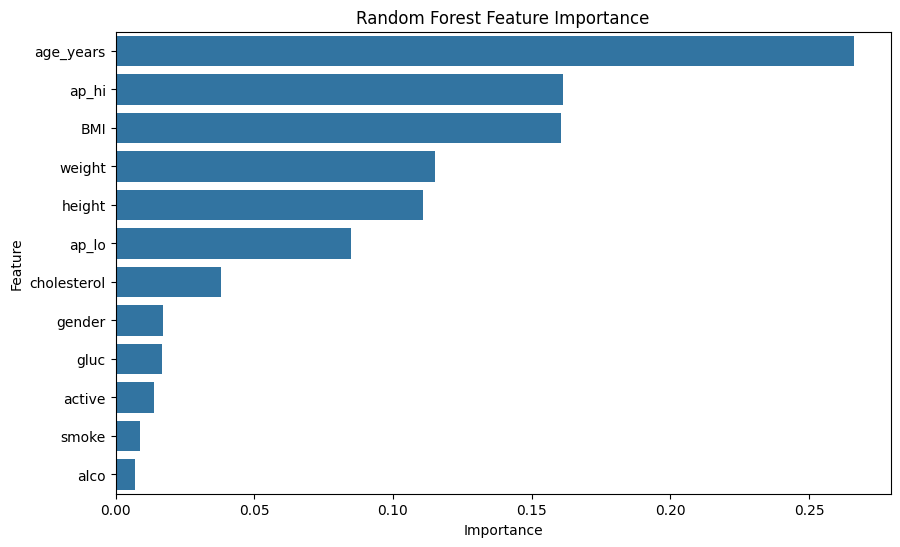

In [33]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

In [34]:
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=4
)

X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train
)

X_test_selected = selector.transform(
    X_test_scaled
)

In [35]:
selected_features = X.columns[
    selector.get_support()
]

print("Selected features:")

for feature in selected_features:
    print("-", feature)

Selected features:
- ap_hi
- ap_lo
- cholesterol
- age_years


In [36]:
from sklearn.preprocessing import MinMaxScaler

quantum_scaler = MinMaxScaler(
    feature_range=(-np.pi, np.pi)
)

X_train_q = quantum_scaler.fit_transform(
    X_train_selected
)

X_test_q = quantum_scaler.transform(
    X_test_selected
)

print(X_train_q.min(), X_train_q.max())

-3.141592653589793 3.141592653589793


In [37]:
from sklearn.model_selection import train_test_split

X_q_train_small, _, y_q_train_small, _ = train_test_split(
    X_train_q,
    y_train,
    train_size=1000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

X_q_test_small, _, y_q_test_small, _ = train_test_split(
    X_test_q,
    y_test,
    train_size=500,
    random_state=RANDOM_STATE,
    stratify=y_test
)

print("Quantum training samples:", len(X_q_train_small))
print("Quantum testing samples:", len(X_q_test_small))

Quantum training samples: 1000
Quantum testing samples: 500


In [42]:
!pip install qiskit qiskit_machine_learning


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

In [39]:
import sys

print("Python:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

import pylatexenc

print("pylatexenc location:")
print(pylatexenc.__file__)

print("pylatexenc version:")
print(getattr(pylatexenc, "__version__", "unknown"))

Python:
c:\Users\shash\AppData\Local\Programs\Python\Python311\python.exe

Python version:
3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
pylatexenc location:
c:\Users\shash\AppData\Local\Programs\Python\Python311\Lib\site-packages\pylatexenc\__init__.py
pylatexenc version:
2.11


In [40]:
from qiskit.utils import optionals

print(bool(optionals.HAS_PYLATEX))

True


In [41]:
from pylatexenc.latex2text import LatexNodes2Text
from pylatexenc.latexencode import utf8tolatex

print("latex2text: OK")
print("latexencode: OK")

latex2text: OK
latexencode: OK


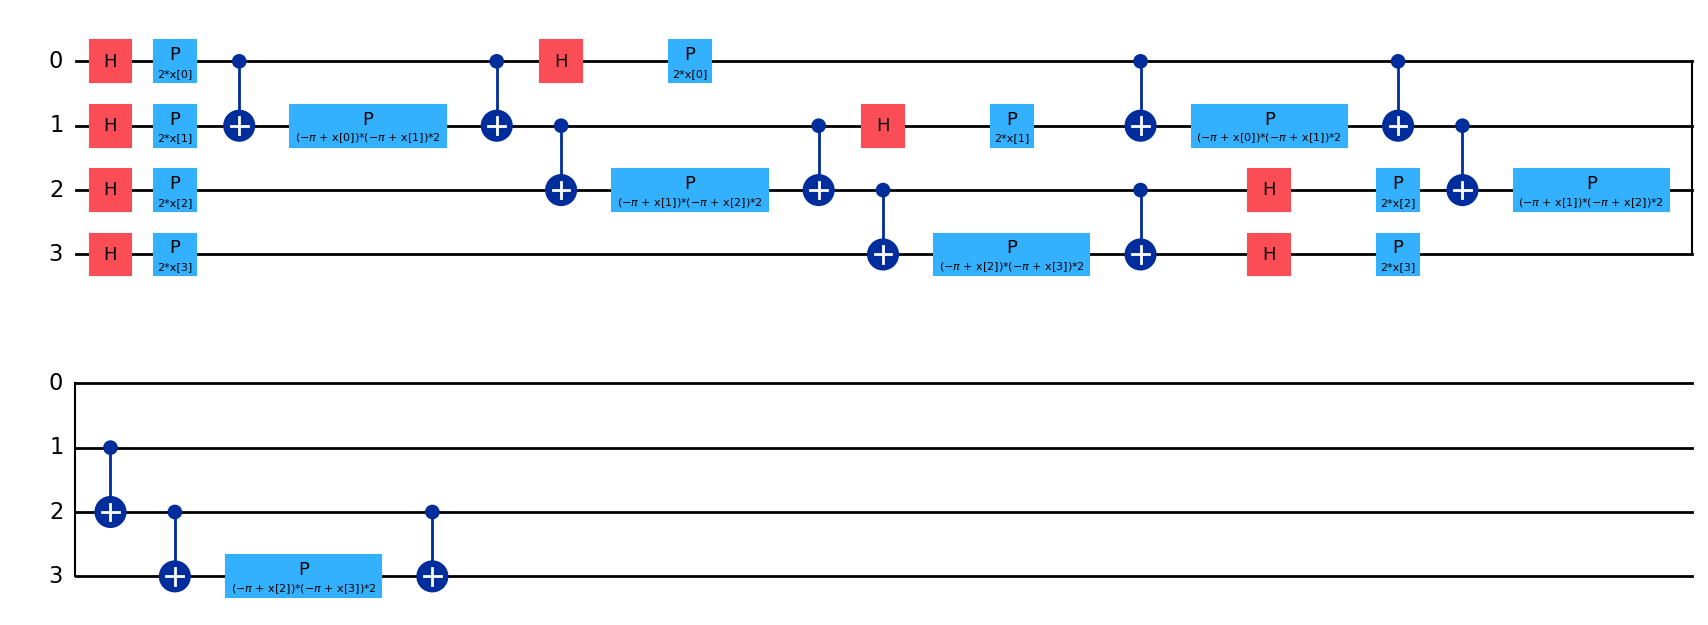

In [43]:
from qiskit.circuit.library import zz_feature_map

num_qubits = 4

feature_map = zz_feature_map(
    feature_dimension=num_qubits,
    reps=2,
    entanglement="linear"
)

feature_map.draw("mpl")

In [44]:
quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

In [45]:
qsvm = QSVC(
    quantum_kernel=quantum_kernel
)

qsvm.fit(
    X_q_train_small,
    y_q_train_small
)

QSVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
     decision_function_shape='ovr', degree=3, gamma='scale', max_iter=-1,
     probability=False,
     quantum_kernel=<qiskit_machine_learning.kernels.fidelity_quantum_kernel.FidelityQuantumKernel object at 0x00000207057B3010>,
     random_state=None, shrinking=True, tol=0.001, verbose=False)

In [46]:
qsvm_pred = qsvm.predict(
    X_q_test_small
)

print(qsvm_pred[:20])

[1 1 0 0 0 0 1 1 0 0 0 1 0 0 0 1 1 0 0 0]


In [47]:
qsvm_accuracy = accuracy_score(
    y_q_test_small,
    qsvm_pred
)

print("QSVM Accuracy:", qsvm_accuracy)

QSVM Accuracy: 0.636


In [48]:
qsvm_precision = precision_score(
    y_q_test_small,
    qsvm_pred
)

qsvm_recall = recall_score(
    y_q_test_small,
    qsvm_pred
)

qsvm_f1 = f1_score(
    y_q_test_small,
    qsvm_pred
)

qsvm_specificity = recall_score(
    y_q_test_small,
    qsvm_pred,
    pos_label=0
)

print("QSVM Results")
print("-----------------------")
print("Accuracy:", qsvm_accuracy)
print("Precision:", qsvm_precision)
print("Sensitivity:", qsvm_recall)
print("Specificity:", qsvm_specificity)
print("F1:", qsvm_f1)

QSVM Results
-----------------------
Accuracy: 0.636
Precision: 0.6775956284153005
Sensitivity: 0.5020242914979757
Specificity: 0.766798418972332
F1: 0.5767441860465117


In [49]:
from sklearn.metrics import roc_auc_score

qsvm_auc = roc_auc_score(
    y_q_test_small,
    qsvm_pred
)

print("QSVM ROC-AUC:", qsvm_auc)

QSVM ROC-AUC: 0.6344113552351538


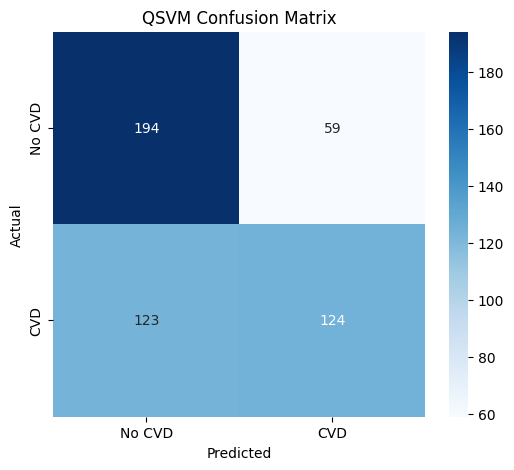

In [50]:
cm = confusion_matrix(
    y_q_test_small,
    qsvm_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No CVD", "CVD"],
    yticklabels=["No CVD", "CVD"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("QSVM Confusion Matrix")

plt.show()

In [51]:
classical_svm_q = SVC(
    kernel="rbf",
    probability=True,
    random_state=RANDOM_STATE
)

classical_svm_q.fit(
    X_q_train_small,
    y_q_train_small
)

classical_svm_q_pred = classical_svm_q.predict(
    X_q_test_small
)

classical_svm_q_prob = classical_svm_q.predict_proba(
    X_q_test_small
)[:, 1]

In [52]:
classical_svm_q_results = evaluate_model(
    "Classical SVM - 4 Features",
    y_q_test_small,
    classical_svm_q_pred,
    classical_svm_q_prob
)

classical_svm_q_results

{'Model': 'Classical SVM - 4 Features',
 'Accuracy': 0.72,
 'Precision': 0.7488372093023256,
 'Recall': 0.6518218623481782,
 'Specificity': 0.7865612648221344,
 'F1': 0.696969696969697,
 'ROC-AUC': np.float64(0.775151621833544)}

In [53]:
quantum_results = {
    "Model": "QSVM - 4 Features",
    "Accuracy": accuracy_score(
        y_q_test_small,
        qsvm_pred
    ),
    "Precision": precision_score(
        y_q_test_small,
        qsvm_pred
    ),
    "Recall": recall_score(
        y_q_test_small,
        qsvm_pred
    ),
    "Specificity": recall_score(
        y_q_test_small,
        qsvm_pred,
        pos_label=0
    ),
    "F1": f1_score(
        y_q_test_small,
        qsvm_pred
    ),
    "ROC-AUC": roc_auc_score(
        y_q_test_small,
        qsvm_pred
    )
}

In [54]:
comparison = pd.DataFrame([
    classical_svm_q_results,
    quantum_results
])

comparison

,Model,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC
0,Classical SVM - 4 Features,0.720,0.748837,0.651822,0.786561,0.696970,0.775152
1,QSVM - 4 Features,0.636,0.677596,0.502024,0.766798,0.576744,0.634411


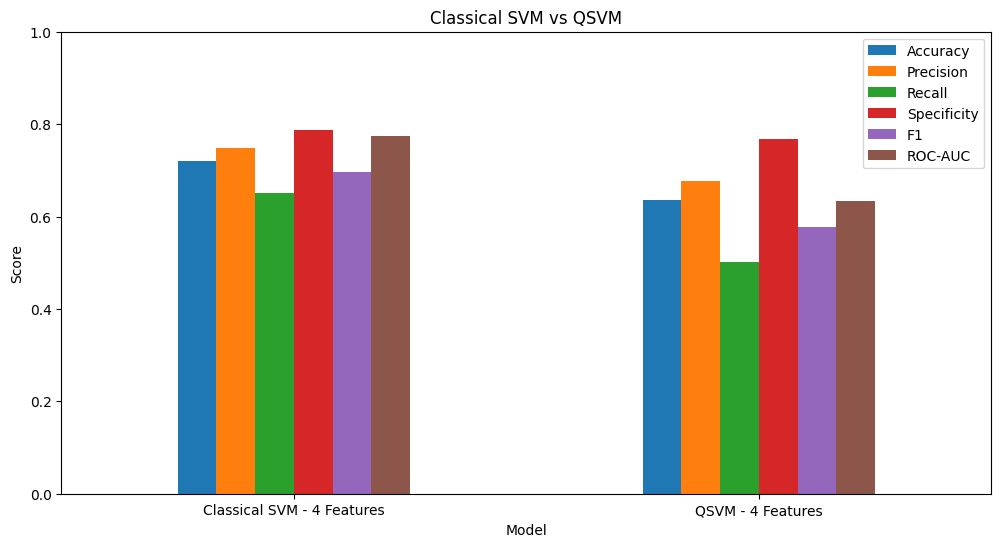

In [55]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC-AUC"
]

comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classical SVM vs QSVM")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

In [56]:
N_TRAIN = 250
N_TEST = 250

X_train_exp4, _, y_train_exp4, _ = train_test_split(
    X_train,
    y_train,
    train_size=N_TRAIN,
    random_state=42,
    stratify=y_train
)

X_test_exp4, _, y_test_exp4, _ = train_test_split(
    X_test,
    y_test,
    train_size=N_TEST,
    random_state=42,
    stratify=y_test
)

print("Training samples:", len(X_train_exp4))
print("Test samples:", len(X_test_exp4))

print("\nTraining distribution:")
print(y_train_exp4.value_counts())

print("\nTest distribution:")
print(y_test_exp4.value_counts())

Training samples: 250
Test samples: 250

Training distribution:
cardio
0    126
1    124
Name: count, dtype: int64

Test distribution:
cardio
0    126
1    124
Name: count, dtype: int64


In [57]:
all_features = [
    "age_years",
    "gender",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "BMI"
]

selected_features = [
    "age_years",
    "ap_hi",
    "BMI",
    "weight"
]

print("All features:", len(all_features))
print("Selected features:", selected_features)

All features: 12
Selected features: ['age_years', 'ap_hi', 'BMI', 'weight']


In [58]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Extract full feature set
# ------------------------------------------------------------

X_train_full = X_train_exp4[all_features].copy()
X_test_full = X_test_exp4[all_features].copy()


# ------------------------------------------------------------
# Standardize
# ------------------------------------------------------------

pca_scaler = StandardScaler()

X_train_scaled = pca_scaler.fit_transform(
    X_train_full
)

X_test_scaled = pca_scaler.transform(
    X_test_full
)


# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------

pca = PCA(n_components=4)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)


print("Original dimensions:", X_train_full.shape[1])
print("PCA dimensions:", X_train_pca.shape[1])

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance retained:",
      pca.explained_variance_ratio_.sum())

Original dimensions: 12
PCA dimensions: 4

Explained variance ratio:
[0.22532086 0.15205161 0.11368762 0.10154795]

Total variance retained: 0.5926080401662825


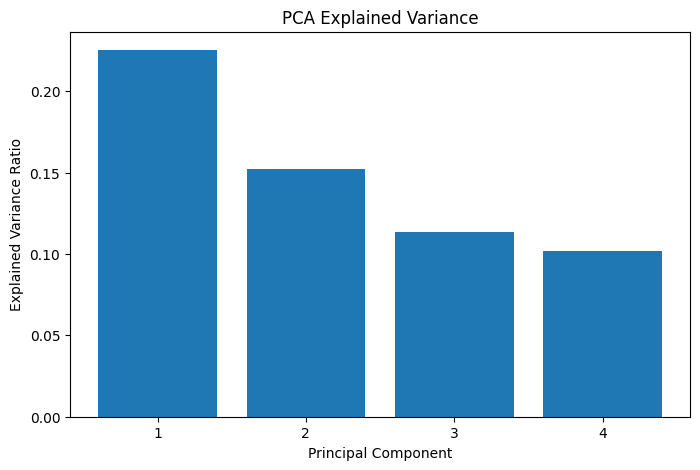

In [59]:
import matplotlib.pyplot as plt

components = np.arange(1, 5)

plt.figure(figsize=(8, 5))

plt.bar(
    components,
    pca.explained_variance_ratio_
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")

plt.xticks(components)

plt.show()

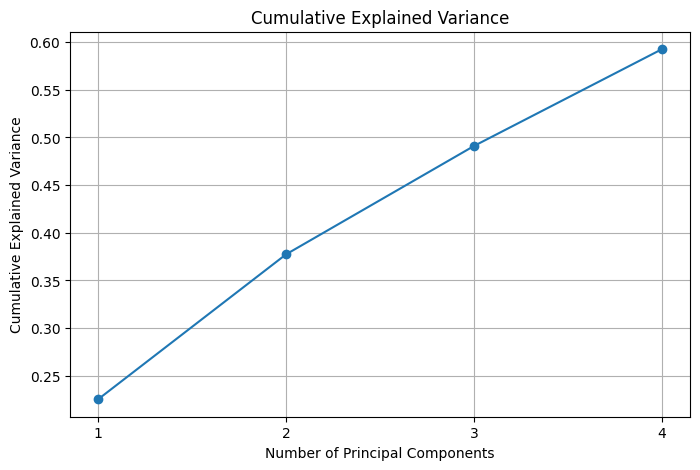

In [60]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8, 5))

plt.plot(
    components,
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.xticks(components)
plt.grid(True)

plt.show()

In [61]:
X_train_selected = X_train_exp4[
    selected_features
].copy()

X_test_selected = X_test_exp4[
    selected_features
].copy()

In [62]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

selected_quantum_scaler = MinMaxScaler(
    feature_range=(-np.pi, np.pi)
)

X_train_selected_q = selected_quantum_scaler.fit_transform(
    X_train_selected
)

X_test_selected_q = selected_quantum_scaler.transform(
    X_test_selected
)

In [63]:
pca_quantum_scaler = MinMaxScaler(
    feature_range=(-np.pi, np.pi)
)

X_train_pca_q = pca_quantum_scaler.fit_transform(
    X_train_pca
)

X_test_pca_q = pca_quantum_scaler.transform(
    X_test_pca
)

In [64]:
from qiskit.circuit.library import zz_feature_map

feature_map = zz_feature_map(
    feature_dimension=4,
    reps=2,
    entanglement="linear"
)

print(feature_map)

   ┌───┐┌───────────┐                                          ┌───┐»
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■──┤ H ├»
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐└───┘»
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├──■──»
   ├───┤├───────────┤└───┘└──────────────────────────────┘└───┘┌─┴─┐»
2: ┤ H ├┤ P(2*x[2]) ├──────────────────────────────────────────┤ X ├»
   ├───┤├───────────┤                                          └───┘»
3: ┤ H ├┤ P(2*x[3]) ├───────────────────────────────────────────────»
   └───┘└───────────┘                                               »
«            ┌───────────┐                                                    »
«0: ─────────┤ P(2*x[0]) ├────────────────────────────────────────────────────»
«            └───────────┘               ┌───┐         ┌───────────┐          »
«1: ──────────────────────────────────■──┤ H ├─────────┤ P(2*x[1]) ├──────────»
«   ┌──────────────────────────────┐┌─┴─┐└───┘    

In [65]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

import time

quantum_kernel_selected = FidelityQuantumKernel(
    feature_map=feature_map
)

qsvm_selected = QSVC(
    quantum_kernel=quantum_kernel_selected
)

print("Training QSVM using selected features...")

start = time.time()

qsvm_selected.fit(
    X_train_selected_q,
    y_train_exp4
)

selected_pred = qsvm_selected.predict(
    X_test_selected_q
)

selected_time = time.time() - start

try:
    selected_score = qsvm_selected.decision_function(
        X_test_selected_q
    )

    selected_auc = roc_auc_score(
        y_test_exp4,
        selected_score
    )

except Exception as e:
    print("ROC-AUC unavailable:", e)
    selected_score = None
    selected_auc = np.nan

print("\nSelected Feature QSVM")
print("Accuracy:",
      accuracy_score(y_test_exp4, selected_pred))
print("Precision:",
      precision_score(y_test_exp4, selected_pred,
                      zero_division=0))
print("Recall:",
      recall_score(y_test_exp4, selected_pred,
                   zero_division=0))
print("F1:",
      f1_score(y_test_exp4, selected_pred,
               zero_division=0))
print("ROC-AUC:", selected_auc)
print("Training time:", selected_time, "seconds")

Training QSVM using selected features...

Selected Feature QSVM
Accuracy: 0.488
Precision: 0.48484848484848486
Recall: 0.5161290322580645
F1: 0.5
ROC-AUC: 0.5003200204813109
Training time: 961.1261672973633 seconds


In [66]:
quantum_kernel_pca = FidelityQuantumKernel(
    feature_map=feature_map
)

qsvm_pca = QSVC(
    quantum_kernel=quantum_kernel_pca
)

print("Training QSVM using PCA features...")

start = time.time()

qsvm_pca.fit(
    X_train_pca_q,
    y_train_exp4
)

pca_pred = qsvm_pca.predict(
    X_test_pca_q
)

pca_time = time.time() - start

try:
    pca_score = qsvm_pca.decision_function(
        X_test_pca_q
    )

    pca_auc = roc_auc_score(
        y_test_exp4,
        pca_score
    )

except Exception as e:
    print("ROC-AUC unavailable:", e)
    pca_score = None
    pca_auc = np.nan

print("\nPCA QSVM")
print("Accuracy:",
      accuracy_score(y_test_exp4, pca_pred))
print("Precision:",
      precision_score(y_test_exp4, pca_pred,
                      zero_division=0))
print("Recall:",
      recall_score(y_test_exp4, pca_pred,
                   zero_division=0))
print("F1:",
      f1_score(y_test_exp4, pca_pred,
               zero_division=0))
print("ROC-AUC:", pca_auc)
print("Training time:", pca_time, "seconds")

Training QSVM using PCA features...

PCA QSVM
Accuracy: 0.484
Precision: 0.4806201550387597
Recall: 0.5
F1: 0.4901185770750988
ROC-AUC: 0.49161546338965695
Training time: 805.6292908191681 seconds


In [67]:
results_exp4 = pd.DataFrame([
    {
        "Representation": "Feature Selection",
        "Features": "age_years, ap_hi, BMI, weight",
        "Qubits": 4,
        "Accuracy": accuracy_score(
            y_test_exp4,
            selected_pred
        ),
        "Precision": precision_score(
            y_test_exp4,
            selected_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_exp4,
            selected_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_exp4,
            selected_pred,
            zero_division=0
        ),
        "ROC-AUC": selected_auc,
        "Training Time (sec)": selected_time
    },
    {
        "Representation": "PCA",
        "Features": "PC1, PC2, PC3, PC4",
        "Qubits": 4,
        "Accuracy": accuracy_score(
            y_test_exp4,
            pca_pred
        ),
        "Precision": precision_score(
            y_test_exp4,
            pca_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_exp4,
            pca_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_exp4,
            pca_pred,
            zero_division=0
        ),
        "ROC-AUC": pca_auc,
        "Training Time (sec)": pca_time
    }
])

results_exp4

,Representation,Features,Qubits,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time (sec)
0,Feature Selection,"age_years, ap_hi, BMI, weight",4,0.488,0.484848,0.516129,0.500000,0.500320,961.126167
1,PCA,"PC1, PC2, PC3, PC4",4,0.484,0.480620,0.500000,0.490119,0.491615,805.629291


In [68]:
selected_classical_scaler = StandardScaler()

X_train_selected_c = selected_classical_scaler.fit_transform(
    X_train_selected
)

X_test_selected_c = selected_classical_scaler.transform(
    X_test_selected
)

svm_selected = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_selected.fit(
    X_train_selected_c,
    y_train_exp4
)

selected_classical_pred = svm_selected.predict(
    X_test_selected_c
)

selected_classical_score = svm_selected.predict_proba(
    X_test_selected_c
)[:, 1]

In [69]:
pca_classical_svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

pca_classical_svm.fit(
    X_train_pca_q,
    y_train_exp4
)

pca_classical_pred = pca_classical_svm.predict(
    X_test_scaled[:, :4]
)

pca_classical_score = pca_classical_svm.predict_proba(
    X_test_scaled[:, :4]
)[:, 1]

In [70]:
classical_exp4 = pd.DataFrame([
    {
        "Representation": "Feature Selection",
        "Model": "Classical SVM",
        "Accuracy": accuracy_score(
            y_test_exp4,
            selected_classical_pred
        ),
        "Precision": precision_score(
            y_test_exp4,
            selected_classical_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_exp4,
            selected_classical_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_exp4,
            selected_classical_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_exp4,
            selected_classical_score
        )
    },
    {
        "Representation": "PCA",
        "Model": "Classical SVM",
        "Accuracy": accuracy_score(
            y_test_exp4,
            pca_classical_pred
        ),
        "Precision": precision_score(
            y_test_exp4,
            pca_classical_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_exp4,
            pca_classical_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_exp4,
            pca_classical_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_exp4,
            pca_classical_score
        )
    }
])

classical_exp4

,Representation,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Feature Selection,Classical SVM,0.712,0.700000,0.733871,0.716535,0.746704
1,PCA,Classical SVM,0.560,0.545455,0.677419,0.604317,0.571685


In [71]:
# Corrected Classical SVM using PCA components

pca_classical_svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

# Train using actual PCA components
pca_classical_svm.fit(
    X_train_pca,
    y_train_exp4
)

# Make predictions
pca_classical_pred = pca_classical_svm.predict(
    X_test_pca
)

# Calculate accuracy
print(
    "Corrected PCA Classical SVM Accuracy:",
    accuracy_score(y_test_exp4, pca_classical_pred)
)

# Calculate F1 score
print(
    "Corrected PCA Classical SVM F1:",
    f1_score(
        y_test_exp4,
        pca_classical_pred,
        zero_division=0
    )
)

Corrected PCA Classical SVM Accuracy: 0.712
Corrected PCA Classical SVM F1: 0.6756756756756757


In [72]:
import time
import numpy as np

from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Experiment 5: Shallower quantum circuit
feature_map_r1 = zz_feature_map(
    feature_dimension=4,
    reps=1,
    entanglement="linear"
)

quantum_kernel_r1 = FidelityQuantumKernel(
    feature_map=feature_map_r1
)

qsvm_r1 = QSVC(
    quantum_kernel=quantum_kernel_r1
)

print("Training QSVM with reps=1...")
start = time.time()

qsvm_r1.fit(
    X_train_selected_q,
    y_train_exp4
)

pred_r1 = qsvm_r1.predict(
    X_test_selected_q
)

runtime_r1 = time.time() - start

score_r1 = qsvm_r1.decision_function(
    X_test_selected_q
)

result_exp5 = {
    "Model": "QSVM reps=1",
    "Qubits": 4,
    "Reps": 1,
    "Accuracy": accuracy_score(y_test_exp4, pred_r1),
    "Precision": precision_score(
        y_test_exp4, pred_r1, zero_division=0
    ),
    "Recall": recall_score(
        y_test_exp4, pred_r1, zero_division=0
    ),
    "F1": f1_score(
        y_test_exp4, pred_r1, zero_division=0
    ),
    "ROC-AUC": roc_auc_score(y_test_exp4, score_r1),
    "Training Time (sec)": runtime_r1
}

print("\nExperiment 5 results:")
for metric, value in result_exp5.items():
    print(f"{metric}: {value}")

Training QSVM with reps=1...

Experiment 5 results:
Model: QSVM reps=1
Qubits: 4
Reps: 1
Accuracy: 0.456
Precision: 0.4411764705882353
Recall: 0.3629032258064516
F1: 0.39823008849557523
ROC-AUC: 0.44751664106502814
Training Time (sec): 541.0850744247437


In [73]:
import time
import numpy as np

from qiskit.circuit.library import z_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ---------------------------------------
# EXPERIMENT 6: Z FEATURE MAP
# ---------------------------------------

# Same number of features/qubits and repetitions
feature_map_z = z_feature_map(
    feature_dimension=4,
    reps=1
)

# Construct the quantum kernel
kernel_z = FidelityQuantumKernel(
    feature_map=feature_map_z
)

# Build the quantum SVM
qsvm_z = QSVC(
    quantum_kernel=kernel_z
)

# Train and evaluate
start_time = time.time()

qsvm_z.fit(
    X_train_selected_q,
    y_train_exp4
)

y_pred_z = qsvm_z.predict(
    X_test_selected_q
)

runtime_z = time.time() - start_time

# Decision scores for ROC-AUC
y_score_z = qsvm_z.decision_function(
    X_test_selected_q
)

# Calculate metrics
accuracy_z = accuracy_score(y_test_exp4, y_pred_z)
precision_z = precision_score(
    y_test_exp4, y_pred_z, zero_division=0
)
recall_z = recall_score(
    y_test_exp4, y_pred_z, zero_division=0
)
f1_z = f1_score(
    y_test_exp4, y_pred_z, zero_division=0
)
auc_z = roc_auc_score(y_test_exp4, y_score_z)

# Confusion matrix
cm_z = confusion_matrix(y_test_exp4, y_pred_z)

# Store results
result_exp6 = {
    "Experiment": "Z Feature Map (reps=1)",
    "Accuracy": accuracy_z,
    "Precision": precision_z,
    "Recall": recall_z,
    "F1 Score": f1_z,
    "ROC-AUC": auc_z,
    "Runtime (seconds)": runtime_z
}

print("EXPERIMENT 6 RESULTS")
print("-" * 40)

for metric, value in result_exp6.items():
    if isinstance(value, (float, np.floating)):
        print(f"{metric}: {value:.4f}")
    else:
        print(f"{metric}: {value}")

print("\nConfusion Matrix:")
print(cm_z)

EXPERIMENT 6 RESULTS
----------------------------------------
Experiment: Z Feature Map (reps=1)
Accuracy: 0.6320
Precision: 0.6290
Recall: 0.6290
F1 Score: 0.6290
ROC-AUC: 0.6539
Runtime (seconds): 487.2022

Confusion Matrix:
[[80 46]
 [46 78]]


In Experiment 6, we evaluated a Z feature map using a four-qubit quantum support vector machine with one circuit repetition. The model achieved an accuracy of 63.20%, precision of 0.6290, recall of 0.6290, F1 score of 0.6290, and ROC-AUC of 0.6539, with a runtime of 487.20 seconds. Compared with the ZZ feature map using one repetition, the Z feature map improved accuracy by 17.60 percentage points and achieved higher values across all reported predictive metrics. This suggests that quantum data encoding is an important experimental parameter. Further validation and comparison with classical models are required before drawing conclusions about practical disease-detection performance.

In [75]:
from sklearn.preprocessing import StandardScaler

selected_features = ["age_years", "ap_hi", "BMI", "weight"]

# Use the same underlying train/test rows as Experiment 4.
# X_train_selected and X_test_selected should be DataFrames.
scaler_selected = StandardScaler()

X_train_selected_scaled = scaler_selected.fit_transform(
    X_train_selected[selected_features]
)

X_test_selected_scaled = scaler_selected.transform(
    X_test_selected[selected_features]
)

In [76]:
import time
import numpy as np
import pandas as pd

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from qiskit.circuit.library import z_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# --------------------------------------------------
# EXPERIMENT 7: CLASSICAL SVM VS QUANTUM SVM
# --------------------------------------------------

# 1. Classical SVM
# Use standardized selected features from Experiment 4.
# If these variables are unavailable, see the note below.
classical_svm = SVC(
    kernel="rbf",
    random_state=42
)

start_classical = time.time()

classical_svm.fit(
    X_train_selected_scaled,
    y_train_exp4
)

pred_classical = classical_svm.predict(
    X_test_selected_scaled
)

score_classical = classical_svm.decision_function(
    X_test_selected_scaled
)

time_classical = time.time() - start_classical

# 2. Quantum SVM with Z feature map
z_map = z_feature_map(
    feature_dimension=4,
    reps=1
)

z_kernel = FidelityQuantumKernel(
    feature_map=z_map
)

quantum_svm = QSVC(
    quantum_kernel=z_kernel
)

start_quantum = time.time()

quantum_svm.fit(
    X_train_selected_q,
    y_train_exp4
)

pred_quantum = quantum_svm.predict(
    X_test_selected_q
)

score_quantum = quantum_svm.decision_function(
    X_test_selected_q
)

time_quantum = time.time() - start_quantum

# 3. Evaluation function
def evaluate_model(name, y_true, predictions, scores, runtime):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(
            y_true, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_true, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_true, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_true, scores),
        "Runtime (seconds)": runtime
    }

results_exp7 = pd.DataFrame([
    evaluate_model(
        "Classical SVM (RBF)",
        y_test_exp4,
        pred_classical,
        score_classical,
        time_classical
    ),
    evaluate_model(
        "Quantum SVM (Z map)",
        y_test_exp4,
        pred_quantum,
        score_quantum,
        time_quantum
    )
])

print("EXPERIMENT 7: MODEL COMPARISON")
display(results_exp7.round(4))

EXPERIMENT 7: MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Runtime (seconds)
0,Classical SVM (RBF),0.712,0.700,0.7339,0.7165,0.7465,0.0217
1,Quantum SVM (Z map),0.632,0.629,0.6290,0.6290,0.6539,755.0195


In [77]:
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# --------------------------------------------------
# EXPERIMENT 8A: CLASSICAL SVM STABILITY TEST
# --------------------------------------------------

# Reconstruct the same 500 samples used in Experiment 4.
# These must be the RAW selected features, before scaling.
X_all = pd.concat(
    [X_train_selected, X_test_selected],
    axis=0
).reset_index(drop=True)

y_all = pd.concat([
    pd.Series(np.asarray(y_train_exp4)),
    pd.Series(np.asarray(y_test_exp4))
], ignore_index=True)

# Five different random seeds
seeds = [42, 21, 7, 100, 123]

splitter = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.5,
    random_state=42
)

results_exp8 = []

for (train_idx, test_idx), seed in zip(
    splitter.split(X_all, y_all), seeds
):
    # Generate a different split for each seed
    rng = np.random.RandomState(seed)

    indices = np.arange(len(X_all))
    rng.shuffle(indices)

    # Stratified split using this seed
    from sklearn.model_selection import train_test_split

    train_idx, test_idx = train_test_split(
        np.arange(len(X_all)),
        test_size=0.5,
        random_state=seed,
        stratify=y_all
    )

    X_train = X_all.iloc[train_idx]
    X_test = X_all.iloc[test_idx]

    y_train = y_all.iloc[train_idx]
    y_test = y_all.iloc[test_idx]

    # Scale using training data only
    model = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", random_state=42)
    )

    start = time.time()

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    scores = model.decision_function(X_test)

    runtime = time.time() - start

    results_exp8.append({
        "Seed": seed,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, scores),
        "Runtime (seconds)": runtime
    })

# Display individual split results
results_exp8_df = pd.DataFrame(results_exp8)

print("EXPERIMENT 8A: RESULTS FOR FIVE RANDOM SEEDS")
display(results_exp8_df.round(4))

# Calculate mean and standard deviation
metric_cols = [
    "Accuracy", "Precision", "Recall",
    "F1 Score", "ROC-AUC"
]

summary_exp8 = pd.DataFrame({
    "Mean": results_exp8_df[metric_cols].mean(),
    "Standard Deviation": results_exp8_df[metric_cols].std()
})

print("MEAN AND STANDARD DEVIATION")
display(summary_exp8.round(4))

EXPERIMENT 8A: RESULTS FOR FIVE RANDOM SEEDS


,Seed,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Runtime (seconds)
0,42,0.716,0.6934,0.7661,0.7280,0.7679,0.0426
1,21,0.708,0.7742,0.5806,0.6636,0.7794,0.0391
2,7,0.728,0.7373,0.7016,0.7190,0.7972,0.0365
3,100,0.732,0.7317,0.7258,0.7287,0.7931,0.0321
4,123,0.740,0.7398,0.7339,0.7368,0.7762,0.0275


MEAN AND STANDARD DEVIATION


,Mean,Standard Deviation
Accuracy,0.7248,0.0128
Precision,0.7353,0.0287
Recall,0.7016,0.0715
F1 Score,0.7152,0.0295
ROC-AUC,0.7828,0.0122


In [78]:
for seed in seeds:
    from sklearn.model_selection import train_test_split
    train_idx, test_idx = train_test_split(
        np.arange(len(X_all)),
        test_size=0.5,
        random_state=seed,
        stratify=y_all
    )

In [79]:
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from qiskit.circuit.library import z_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

# --------------------------------------------------
# EXPERIMENT 8B: QUANTUM SVM STABILITY TEST
# --------------------------------------------------

# Reconstruct the same 500-record subset
X_all = pd.concat(
    [X_train_selected, X_test_selected],
    axis=0
).reset_index(drop=True)

y_all = pd.concat([
    pd.Series(np.asarray(y_train_exp4)),
    pd.Series(np.asarray(y_test_exp4))
], ignore_index=True)

seeds = [42, 21, 7, 100, 123]
results_quantum = []

for seed in seeds:
    print(f"\nRunning quantum SVM for seed {seed}...")

    # Same stratified split procedure as Experiment 8A
    train_idx, test_idx = train_test_split(
        np.arange(len(X_all)),
        test_size=0.5,
        random_state=seed,
        stratify=y_all
    )

    X_train = X_all.iloc[train_idx].to_numpy()
    X_test = X_all.iloc[test_idx].to_numpy()

    y_train = y_all.iloc[train_idx].to_numpy()
    y_test = y_all.iloc[test_idx].to_numpy()

    # Scale only the training data to the quantum encoding range
    scaler_q = MinMaxScaler(
        feature_range=(-np.pi, np.pi)
    )

    X_train_q = scaler_q.fit_transform(X_train)
    X_test_q = scaler_q.transform(X_test)

    # Four-qubit Z feature map, one repetition
    z_map = z_feature_map(
        feature_dimension=4,
        reps=1
    )

    kernel = FidelityQuantumKernel(
        feature_map=z_map
    )

    model = QSVC(
        quantum_kernel=kernel
    )

    start = time.time()

    model.fit(X_train_q, y_train)
    predictions = model.predict(X_test_q)
    scores = model.decision_function(X_test_q)

    runtime = time.time() - start

    result = {
        "Seed": seed,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, scores),
        "Runtime (seconds)": runtime
    }

    results_quantum.append(result)

    print(pd.Series(result).to_string())

# Save results in a DataFrame
results_8b_df = pd.DataFrame(results_quantum)

print("\nEXPERIMENT 8B: QUANTUM SVM RESULTS")
display(results_8b_df.round(4))

# Summary statistics
metrics = [
    "Accuracy", "Precision", "Recall",
    "F1 Score", "ROC-AUC"
]

summary_8b = pd.DataFrame({
    "Mean": results_8b_df[metrics].mean(),
    "Standard Deviation": results_8b_df[metrics].std()
})

print("\nQUANTUM SVM: MEAN AND STANDARD DEVIATION")
display(summary_8b.round(4))


Running quantum SVM for seed 42...
Seed                  42.000000
Accuracy               0.628000
Precision              0.628099
Recall                 0.612903
F1 Score               0.620408
ROC-AUC                0.663082
Runtime (seconds)    795.973454

Running quantum SVM for seed 21...
Seed                  21.000000
Accuracy               0.648000
Precision              0.687500
Recall                 0.532258
F1 Score               0.600000
ROC-AUC                0.673835
Runtime (seconds)    750.259136

Running quantum SVM for seed 7...
Seed                   7.000000
Accuracy               0.612000
Precision              0.609756
Recall                 0.604839
F1 Score               0.607287
ROC-AUC                0.666795
Runtime (seconds)    584.445058

Running quantum SVM for seed 100...
Seed                 100.000000
Accuracy               0.644000
Precision              0.654867
Recall                 0.596774
F1 Score               0.624473
ROC-AUC                0

,Seed,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Runtime (seconds)
0,42,0.628,0.6281,0.6129,0.6204,0.6631,795.9735
1,21,0.648,0.6875,0.5323,0.6000,0.6738,750.2591
2,7,0.612,0.6098,0.6048,0.6073,0.6668,584.4451
3,100,0.644,0.6549,0.5968,0.6245,0.6672,846.6100
4,123,0.632,0.6429,0.5806,0.6102,0.6575,19256.7622



QUANTUM SVM: MEAN AND STANDARD DEVIATION


,Mean,Standard Deviation
Accuracy,0.6328,0.0143
Precision,0.6446,0.0293
Recall,0.5855,0.0321
F1 Score,0.6125,0.0099
ROC-AUC,0.6657,0.0060


Experiment 8 evaluated the stability of classical and quantum support vector machines across five stratified train-test splits of the same 500-record cardiovascular dataset. The classical SVM achieved mean accuracy of 72.48%, mean F1 score of 0.7152, and mean ROC-AUC of 0.7828. The quantum SVM with a Z feature map achieved mean accuracy of 63.28%, mean F1 score of 0.6125, and mean ROC-AUC of 0.6657. Across these five splits, the classical model had higher mean performance on all evaluated metrics. The quantum model also exhibited substantially higher computational cost, including one unusually long run. These findings apply to the selected dataset subset and experimental configuration and do not establish a universal conclusion about quantum machine learning.

In [80]:
import joblib
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Use the raw selected features from Experiment 4
# Keep the exact feature order used in training.
selected_features = [
    "age_years",
    "ap_hi",
    "BMI",
    "weight"
]

X_train_app = X_train_selected[selected_features]

classical_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", random_state=42)
)

classical_model.fit(X_train_app, y_train_exp4)

joblib.dump(
    classical_model,
    "classical_svm.joblib"
)

print("Classical model saved successfully.")

Classical model saved successfully.


In [ ]:
import pandas as pd

benchmark_results = pd.DataFrame([
    {
        "Experiment": "Feature map: ZZ, reps=1",
        "Accuracy": 0.456,
        "F1 Score": 0.3982,
        "ROC-AUC": 0.4475,
        "Runtime (seconds)": 541.085
    },
    {
        "Experiment": "Feature map: Z, reps=1",
        "Accuracy": 0.632,
        "F1 Score": 0.629,
        "ROC-AUC": 0.6539,
        "Runtime (seconds)": 487.2022
    },
    {
        "Experiment": "Classical SVM, Experiment 7",
        "Accuracy": 0.712,
        "F1 Score": 0.7165,
        "ROC-AUC": 0.7465,
        "Runtime (seconds)": 0.0217
    }
])


print(benchmark_results)

                    Experiment  Accuracy  F1 Score  ROC-AUC  Runtime (seconds)
0      Feature map: ZZ, reps=1     0.456    0.3982   0.4475           541.0850
1       Feature map: Z, reps=1     0.632    0.6290   0.6539           487.2022
2  Classical SVM, Experiment 7     0.712    0.7165   0.7465             0.0217


Output directory: C:\Users\shash\OneDrive\Desktop\sih\dataset2\model_benchmark_results
[SAVED] Logistic Regression: model_benchmark_results\models\logistic_regression.joblib
[SAVED] Classical SVM: model_benchmark_results\models\classical_svm.joblib
[SAVED] Random Forest: model_benchmark_results\models\random_forest.joblib
[MISSING] Quantum SVM (Z map): NOT FOUND: variable 'qsvm_model'. Edit MODEL_VARIABLES to match your fitted model variable.
[SAVED PREPROCESSOR] quantum_scaler: model_benchmark_results\models\quantum_scaler.joblib
[SAVED PREPROCESSOR] classical_scaler: model_benchmark_results\models\classical_scaler.joblib

Saved benchmark CSV files and: model_benchmark_results\all_benchmark_tables.xlsx


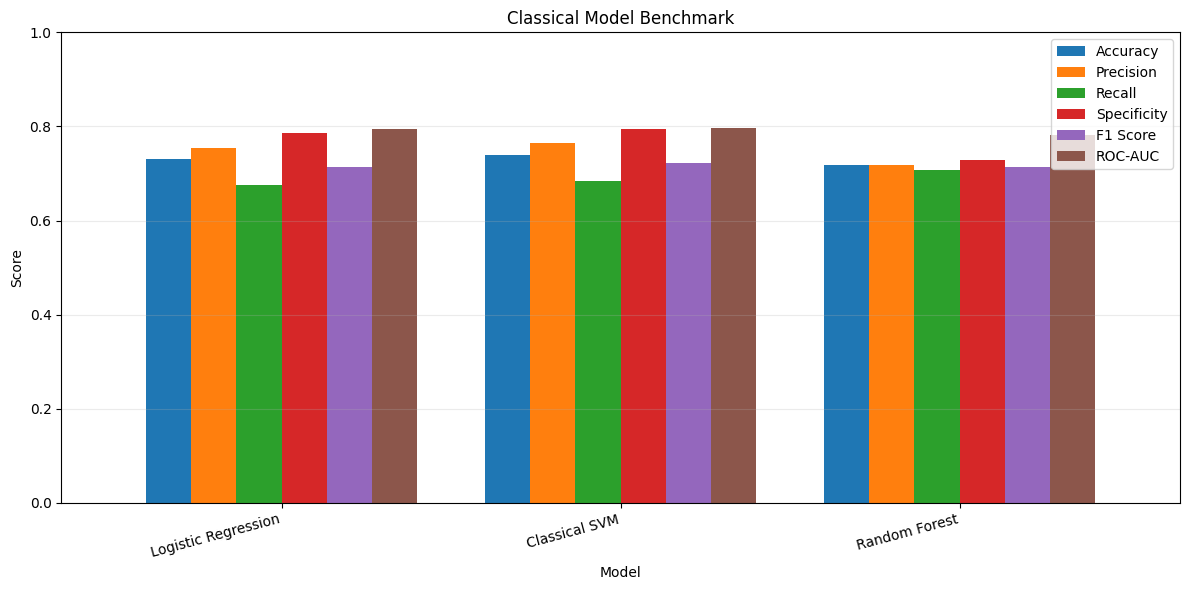

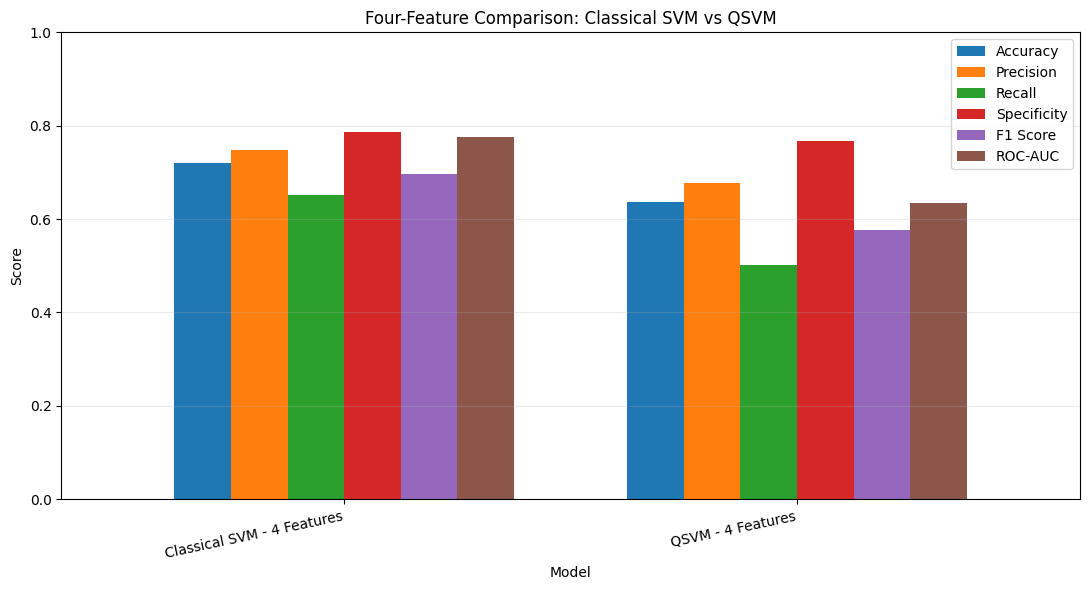

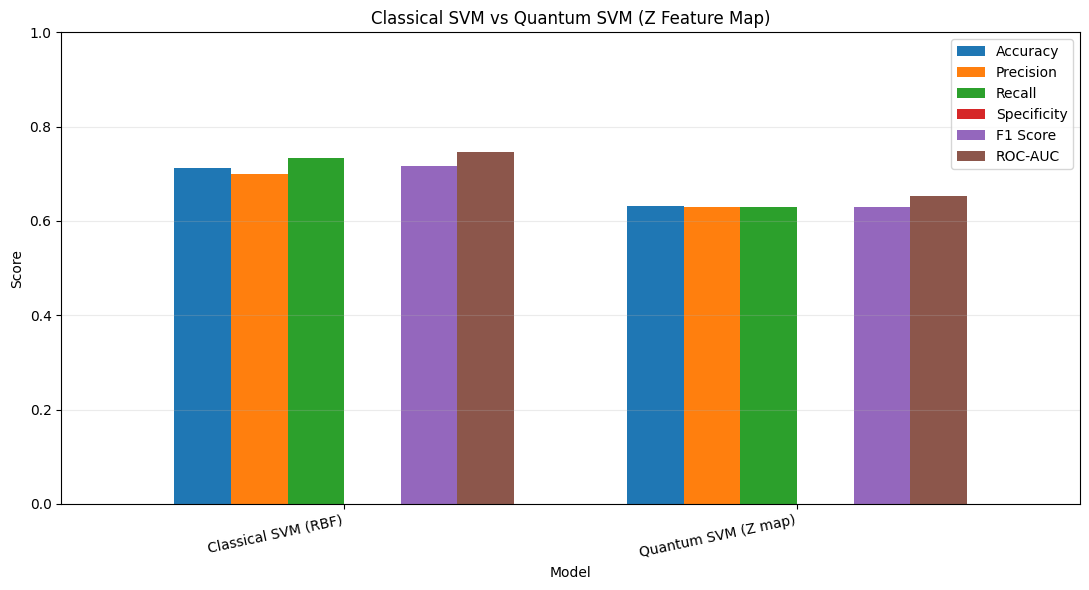

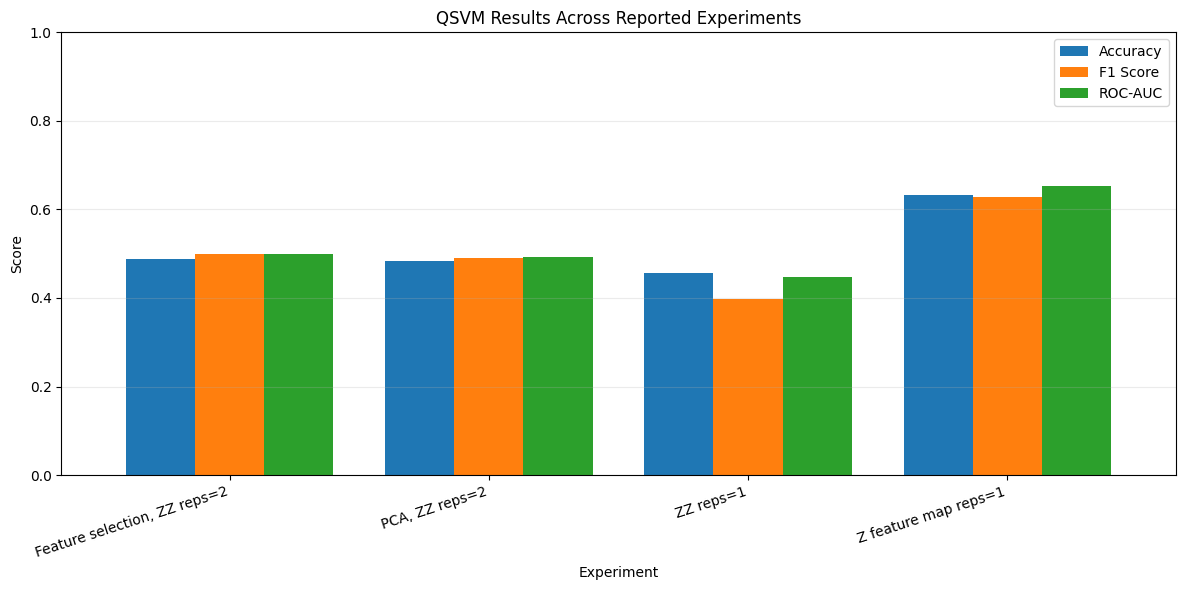

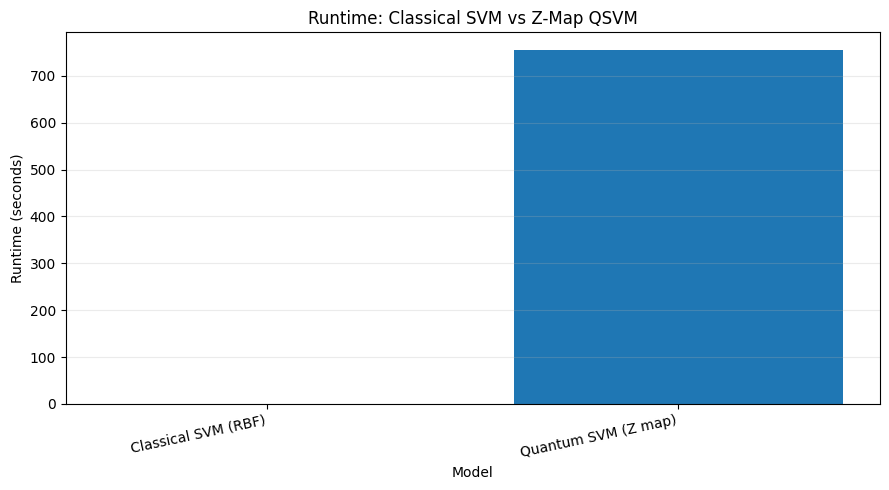

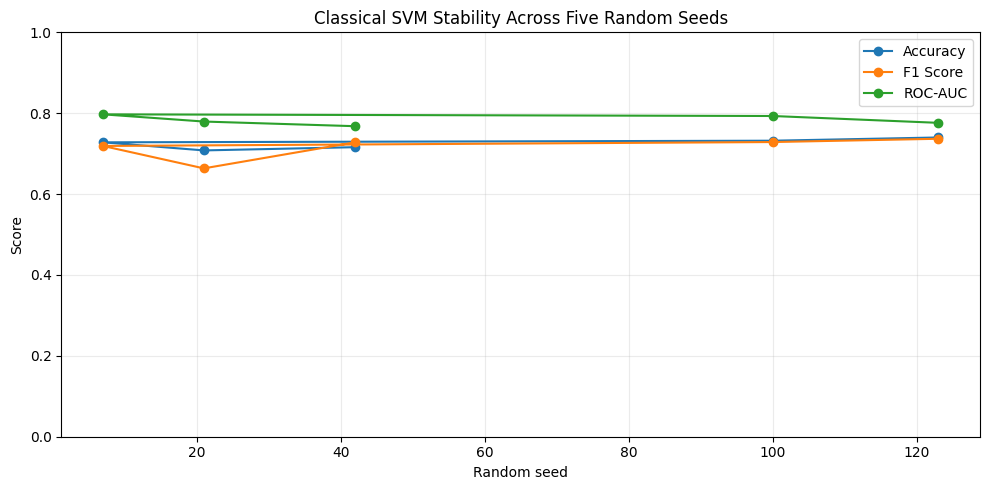

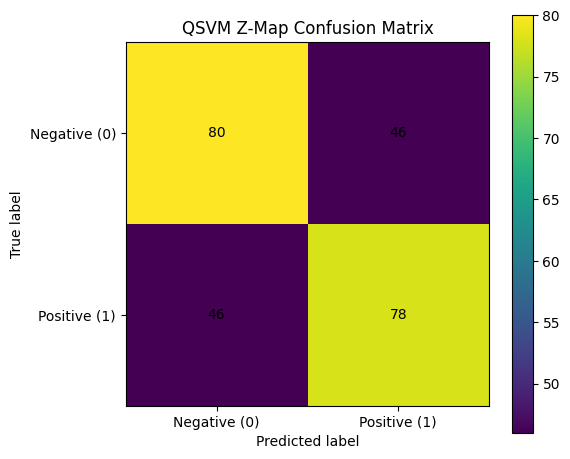


EXPORT FINISHED
Output folder: C:\Users\shash\OneDrive\Desktop\sih\dataset2\model_benchmark_results
ZIP archive: C:\Users\shash\OneDrive\Desktop\sih\dataset2\model_benchmark_results.zip

Model save status:
              Model                                                      File                                                                                      Status
Logistic Regression model_benchmark_results\models\logistic_regression.joblib                                                                          Saved and reloaded
      Classical SVM       model_benchmark_results\models\classical_svm.joblib                                                                          Saved and reloaded
      Random Forest       model_benchmark_results\models\random_forest.joblib                                                                          Saved and reloaded
Quantum SVM (Z map)                                                           NOT FOUND: variable 'qsvm_model'. E

In [84]:
from pathlib import Path
import json
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. LOCAL OUTPUT FOLDERS
# ============================================================

OUTPUT_DIR = Path("model_benchmark_results")
MODEL_DIR = OUTPUT_DIR / "models"
GRAPH_DIR = OUTPUT_DIR / "graphs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())

# ============================================================
# 2. CONNECT YOUR FOUR ALREADY-TRAINED MODEL OBJECTS
#
# Change these strings if your fitted model variables have other names.
# Examples: "log_reg", "classical_svm", "random_forest", "qsvc"
#
# Use complete fitted pipelines when possible, so preprocessing is saved
# together with the model. If a scaler is separate, save it separately.
# ============================================================

MODEL_VARIABLES = {
    "Logistic Regression": "lr_model",
    "Classical SVM": "svm_model",
    "Random Forest": "rf_model",
    "Quantum SVM (Z map)": "qsvm_model",
}

# This cell/script is intended to run in the same Python kernel as training.
# If running as a standalone .py file, import/load your trained models here.
available_namespace = globals()
trained_models = {
    model_name: available_namespace.get(variable_name)
    for model_name, variable_name in MODEL_VARIABLES.items()
}

# Optional fitted preprocessing objects to save.
# Change the variable names if you use separate scalers/preprocessors.
OPTIONAL_PREPROCESSORS = {
    "quantum_scaler": "quantum_scaler",
    "classical_scaler": "scaler",
}

# ============================================================
# 3. SAVE MODELS AND VERIFY RELOADING
# ============================================================

save_status = []

def safe_filename(name):
    return (
        name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("-", "_")
    )

for model_name, model in trained_models.items():
    if model is None:
        variable_name = MODEL_VARIABLES[model_name]
        message = (
            f"NOT FOUND: variable '{variable_name}'. "
            "Edit MODEL_VARIABLES to match your fitted model variable."
        )
        print(f"[MISSING] {model_name}: {message}")
        save_status.append({
            "Model": model_name,
            "File": "",
            "Status": message
        })
        continue

    model_path = MODEL_DIR / f"{safe_filename(model_name)}.joblib"

    try:
        joblib.dump(model, model_path)
        # Basic serialization check
        reloaded = joblib.load(model_path)
        save_status.append({
            "Model": model_name,
            "File": str(model_path),
            "Status": "Saved and reloaded"
        })
        print(f"[SAVED] {model_name}: {model_path}")
    except Exception as exc:
        save_status.append({
            "Model": model_name,
            "File": str(model_path),
            "Status": f"SAVE FAILED: {type(exc).__name__}: {exc}"
        })
        print(f"[ERROR] Could not save {model_name}: {exc}")
        if "Quantum" in model_name:
            print(
                "Qiskit note: some quantum objects may need a compatible "
                "Qiskit version or saving the underlying circuit/kernel "
                "and rebuilding the QSVM when loading."
            )

# Save optional preprocessing objects, if present.
for saved_name, variable_name in OPTIONAL_PREPROCESSORS.items():
    obj = available_namespace.get(variable_name)
    if obj is not None:
        try:
            path = MODEL_DIR / f"{saved_name}.joblib"
            joblib.dump(obj, path)
            joblib.load(path)
            print(f"[SAVED PREPROCESSOR] {saved_name}: {path}")
        except Exception as exc:
            print(f"[WARNING] Could not save {saved_name}: {exc}")

save_status_df = pd.DataFrame(save_status)
save_status_df.to_csv(OUTPUT_DIR / "model_save_status.csv", index=False)

# ============================================================
# 4. BENCHMARK TABLE A: YOUR THREE-MODEL CLASSICAL BENCHMARK
# These values are copied from the first supplied results table.
# ============================================================

classical_reference = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.730786,
        "Precision": 0.755018,
        "Recall": 0.674952,
        "Specificity": 0.785478,
        "F1 Score": 0.712744,
        "ROC-AUC": 0.795360,
        "Runtime (seconds)": np.nan,
        "Experiment/Setup": "Original classical benchmark; setup not specified here",
    },
    {
        "Model": "Classical SVM",
        "Accuracy": 0.739665,
        "Precision": 0.764706,
        "Recall": 0.684512,
        "Specificity": 0.793690,
        "F1 Score": 0.722390,
        "ROC-AUC": 0.797644,
        "Runtime (seconds)": np.nan,
        "Experiment/Setup": "Original classical benchmark; setup not specified here",
    },
    {
        "Model": "Random Forest",
        "Accuracy": 0.718195,
        "Precision": 0.718792,
        "Recall": 0.707163,
        "Specificity": 0.729002,
        "F1 Score": 0.712930,
        "ROC-AUC": 0.780779,
        "Runtime (seconds)": np.nan,
        "Experiment/Setup": "Original classical benchmark; setup not specified here",
    },
])

# ============================================================
# 5. BENCHMARK TABLE B: FOUR-FEATURE SVM VS QSVM
# Values copied from your supplied 4-feature table.
# This is the most relevant direct SVM-vs-QSVM comparison among
# the tables you provided, assuming both rows used the same test set.
# ============================================================

four_feature_comparison = pd.DataFrame([
    {
        "Model": "Classical SVM - 4 Features",
        "Accuracy": 0.720,
        "Precision": 0.74887,
        "Recall": 0.651822,
        "Specificity": 0.78651,
        "F1 Score": 0.696970,
        "ROC-AUC": 0.775152,
        "Runtime (seconds)": np.nan,
        "Features/Setup": "age_years, ap_hi, BMI, weight",
    },
    {
        "Model": "QSVM - 4 Features",
        "Accuracy": 0.636,
        "Precision": 0.67796,
        "Recall": 0.50204,
        "Specificity": 0.76698,
        "F1 Score": 0.57644,
        "ROC-AUC": 0.63411,
        "Runtime (seconds)": np.nan,
        "Features/Setup": "age_years, ap_hi, BMI, weight; 4 qubits",
    },
])

# ============================================================
# 6. BENCHMARK TABLE C: CLASSICAL SVM VS Z-FEATURE-MAP QSVM
# Values copied from your supplied latest runtime comparison.
# Keep separate from Table B because the metrics differ by experiment.
# ============================================================

z_map_comparison = pd.DataFrame([
    {
        "Model": "Classical SVM (RBF)",
        "Accuracy": 0.712,
        "Precision": 0.700,
        "Recall": 0.7339,
        "Specificity": np.nan,
        "F1 Score": 0.7165,
        "ROC-AUC": 0.7465,
        "Runtime (seconds)": 0.0217,
        "Experiment/Setup": "SVM vs Z-map QSVM experiment",
    },
    {
        "Model": "Quantum SVM (Z map)",
        "Accuracy": 0.632,
        "Precision": 0.629,
        "Recall": 0.6290,
        "Specificity": np.nan,
        "F1 Score": 0.6290,
        "ROC-AUC": 0.6539,
        "Runtime (seconds)": 755.0195,
        "Experiment/Setup": "Z feature map, reps=1; 4 selected features",
    },
])

# ============================================================
# 7. BENCHMARK TABLE D: QSVM REPRESENTATION / CONFIGURATION EXPERIMENTS
# These settings differ, so use this as an experiment summary,
# not as a strictly controlled leaderboard.
# ============================================================

qsvm_experiments = pd.DataFrame([
    {
        "Experiment": "Feature selection, ZZ reps=2",
        "Representation": "age_years, ap_hi, BMI, weight",
        "Qubits": 4,
        "Accuracy": 0.488,
        "Precision": 0.4848484848,
        "Recall": 0.5161290323,
        "F1 Score": 0.500000,
        "ROC-AUC": 0.5003200205,
        "Runtime (seconds)": np.nan,
    },
    {
        "Experiment": "PCA, ZZ reps=2",
        "Representation": "PC1, PC2, PC3, PC4",
        "Qubits": 4,
        "Accuracy": 0.484,
        "Precision": 0.4806201550,
        "Recall": 0.500000,
        "F1 Score": 0.4901185771,
        "ROC-AUC": 0.4916154634,
        "Runtime (seconds)": np.nan,
    },
    {
        "Experiment": "ZZ reps=1",
        "Representation": "4 selected features",
        "Qubits": 4,
        "Accuracy": 0.456,
        "Precision": 0.4411764706,
        "Recall": 0.3629032258,
        "F1 Score": 0.3982300885,
        "ROC-AUC": 0.4475166411,
        "Runtime (seconds)": 541.085,
    },
    {
        "Experiment": "Z feature map reps=1",
        "Representation": "4 selected features",
        "Qubits": 4,
        "Accuracy": 0.632,
        "Precision": 0.629,
        "Recall": 0.629,
        "F1 Score": 0.629,
        "ROC-AUC": 0.6539,
        "Runtime (seconds)": 487.2022,
    },
])

# ============================================================
# 8. CLASSICAL SVM RANDOM-SEED STABILITY TABLE
# Values copied from Experiment 8A.
# ============================================================

svm_stability = pd.DataFrame([
    {"Seed": 42,  "Accuracy": 0.716, "Precision": 0.6934, "Recall": 0.7661, "F1 Score": 0.7280, "ROC-AUC": 0.7679},
    {"Seed": 21,  "Accuracy": 0.708, "Precision": 0.7742, "Recall": 0.5806, "F1 Score": 0.6636, "ROC-AUC": 0.7794},
    {"Seed": 7,   "Accuracy": 0.728, "Precision": 0.7373, "Recall": 0.7016, "F1 Score": 0.7190, "ROC-AUC": 0.7972},
    {"Seed": 100, "Accuracy": 0.732, "Precision": 0.7317, "Recall": 0.7258, "F1 Score": 0.7287, "ROC-AUC": 0.7931},
    {"Seed": 123, "Accuracy": 0.740, "Precision": 0.7398, "Recall": 0.7339, "F1 Score": 0.7368, "ROC-AUC": 0.7762},
])

stability_summary = (
    svm_stability[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]]
    .agg(["mean", "std"])
    .T
    .reset_index()
    .rename(columns={"index": "Metric", "mean": "Mean", "std": "Sample SD"})
)

# ============================================================
# 9. SAVE CSV TABLES AND ONE EXCEL WORKBOOK
# ============================================================

tables = {
    "classical_reference": classical_reference,
    "four_feature_svm_qsvm": four_feature_comparison,
    "z_map_svm_qsvm": z_map_comparison,
    "qsvm_experiments": qsvm_experiments,
    "svm_seed_stability": svm_stability,
    "svm_stability_summary": stability_summary,
}

for name, df in tables.items():
    df.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)

excel_path = OUTPUT_DIR / "all_benchmark_tables.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("\nSaved benchmark CSV files and:", excel_path)

# ============================================================
# 10. GRAPH 1: CLASSICAL MODEL REFERENCE BENCHMARK
# ============================================================

metrics = ["Accuracy", "Precision", "Recall", "Specificity", "F1 Score", "ROC-AUC"]

ax = classical_reference.set_index("Model")[metrics].plot(
    kind="bar", figsize=(12, 6), width=0.8
)
ax.set_title("Classical Model Benchmark")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "classical_model_metrics.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# 11. GRAPH 2: FOUR-FEATURE CLASSICAL SVM VS QSVM
# ============================================================

ax = four_feature_comparison.set_index("Model")[metrics].plot(
    kind="bar", figsize=(11, 6), width=0.75
)
ax.set_title("Four-Feature Comparison: Classical SVM vs QSVM")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "four_feature_svm_qsvm_metrics.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# 12. GRAPH 3: Z-MAP SVM VS QSVM METRICS
# ============================================================

ax = z_map_comparison.set_index("Model")[metrics].plot(
    kind="bar", figsize=(11, 6), width=0.75
)
ax.set_title("Classical SVM vs Quantum SVM (Z Feature Map)")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "z_map_svm_qsvm_metrics.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# 13. GRAPH 4: QSVM CONFIGURATION / REPRESENTATION EXPERIMENTS
# Settings differ; graph is a summary of reported experiments.
# ============================================================

ax = qsvm_experiments.set_index("Experiment")[["Accuracy", "F1 Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(12, 6), width=0.8
)
ax.set_title("QSVM Results Across Reported Experiments")
ax.set_xlabel("Experiment")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=18, ha="right")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "qsvm_experiment_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# 14. GRAPH 5: RUNTIME COMPARISON FOR THE Z-MAP EXPERIMENT
# ============================================================

runtime_data = z_map_comparison.dropna(subset=["Runtime (seconds)"])

plt.figure(figsize=(9, 5))
plt.bar(runtime_data["Model"], runtime_data["Runtime (seconds)"])
plt.title("Runtime: Classical SVM vs Z-Map QSVM")
plt.xlabel("Model")
plt.ylabel("Runtime (seconds)")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.savefig(GRAPH_DIR / "z_map_runtime_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# 15. GRAPH 6: CLASSICAL SVM STABILITY ACROSS RANDOM SEEDS
# ============================================================

ax = svm_stability.set_index("Seed")[["Accuracy", "F1 Score", "ROC-AUC"]].plot(
    kind="line", marker="o", figsize=(10, 5)
)
ax.set_title("Classical SVM Stability Across Five Random Seeds")
ax.set_xlabel("Random seed")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(GRAPH_DIR / "svm_seed_stability.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# ============================================================
# 16. SAVE CONFUSION MATRIX FROM THE Z-MAP EXPERIMENT
# Matrix order: [[TN, FP], [FN, TP]]
# As supplied: [[80, 46], [46, 78]]
# ============================================================

cm = np.array([[80, 46], [46, 78]])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest")
ax.set_title("QSVM Z-Map Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1], labels=["Negative (0)", "Positive (1)"])
ax.set_yticks([0, 1], labels=["Negative (0)", "Positive (1)"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")

fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(GRAPH_DIR / "qsvm_z_map_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Save confusion matrix as CSV too.
pd.DataFrame(
    cm,
    index=["Actual negative", "Actual positive"],
    columns=["Predicted negative", "Predicted positive"]
).to_csv(OUTPUT_DIR / "qsvm_z_map_confusion_matrix.csv")

# ============================================================
# 17. README AND METADATA
# ============================================================

readme = """HYBRID QUANTUM MACHINE LEARNING PROJECT - BENCHMARK EXPORT

Contents:
- models/: saved fitted model objects, if the objects were found and serializable
- graphs/: metric and runtime comparison graphs
- classical_reference.csv: supplied Logistic Regression, Classical SVM, Random Forest results
- four_feature_svm_qsvm.csv: direct four-feature SVM/QSVM results
- z_map_svm_qsvm.csv: supplied Z-map SVM/QSVM results including runtime
- qsvm_experiments.csv: feature-selection, PCA, ZZ and Z-map results
- svm_seed_stability.csv: classical SVM metrics for five seeds
- svm_stability_summary.csv: mean and sample standard deviation
- all_benchmark_tables.xlsx: all tables in separate worksheets
- model_save_status.csv: model serialization status

Interpretation:
1. Do not merge results from different experiments into one definitive ranking.
2. The original classical benchmark and the QSVM experiments may use different
   feature sets, splits, and configurations.
3. The four-feature SVM/QSVM table is the most relevant direct comparison
   among the supplied four-feature results, provided both rows used the same
   test split.
4. In the separate Z-map run, the classical SVM took 0.0217 seconds and the
   QSVM took 755.0195 seconds. Runtime is experiment-specific.
5. The QSVM confusion matrix is saved exactly as supplied.
6. This is an experimental research prototype, not a clinically validated
   diagnostic system.
"""

(OUTPUT_DIR / "README.txt").write_text(readme, encoding="utf-8")

metadata = {
    "project": "Hybrid Quantum Machine Learning Platform for Early Disease Detection",
    "model_variable_aliases": MODEL_VARIABLES,
    "benchmark_tables": list(tables.keys()),
    "note": "Results from different experiments are kept in separate tables."
}
(OUTPUT_DIR / "metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8"
)

# ============================================================
# 18. ZIP EVERYTHING
# ============================================================

ZIP_PATH = Path("model_benchmark_results.zip")

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in OUTPUT_DIR.rglob("*"):
        if file_path.is_file():
            zipf.write(file_path, arcname=file_path.relative_to(OUTPUT_DIR.parent))

print("\n" + "=" * 65)
print("EXPORT FINISHED")
print("=" * 65)
print("Output folder:", OUTPUT_DIR.resolve())
print("ZIP archive:", ZIP_PATH.resolve())
print("\nModel save status:")
print(save_status_df.to_string(index=False))
print("\nGenerated files:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(" -", path)
